# Classificação de Gênero Musical com CNN — GTZAN Dataset

Este notebook implementa uma **Convolutional Neural Network (CNN)** para classificação automática de gêneros musicais usando o **GTZAN Dataset**, com os folds de validação cruzada estratificada com filtro de artista propostos por Sturm (2013).

**Referência dos folds:**
> Foleis, J. H., & Tavares, T. F. (2020). *Texture selection for automatic music genre classification*. Applied Soft Computing, 89, 106127.

**Pipeline:**
1. Download dos folds via GitHub
2. Carregamento e pré-processamento dos áudios (Mel-Spectrograma)
3. Definição da arquitetura CNN
4. Treinamento com validação cruzada 3-fold
5. Avaliação e visualização dos resultados

**Gêneros:** blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock

## 1. Instalação de Dependências

In [24]:
# Instalar dependências necessárias
!pip install librosa torch torchvision torchaudio scikit-learn matplotlib seaborn tqdm -q

## 2. Imports e Configurações

In [25]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import urllib.request
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Reproducibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

# Info da GPU (se disponível)
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memória: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠ GPU não detectada. Vá em Runtime → Change runtime type → T4 GPU')

# Gêneros do GTZAN
GENRES = ['blues', 'classical', 'country', 'disco',
          'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE = {i: g for g, i in GENRE2IDX.items()}
print(f'Gêneros: {GENRES}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dispositivo: cuda
GPU: Tesla T4
Memória: 15.6 GB
Gêneros: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 3. Download dos Folds (Sturm Filter)

In [26]:
BASE_URL = 'https://raw.githubusercontent.com/julianofoleiss/gtzan_sturm_filter_3folds_stratified/master/'
FOLDS_DIR = Path('gtzan_folds')
FOLDS_DIR.mkdir(exist_ok=True)

fold_files = []
for fold in range(1, 4):
    for split in ['train', 'test', 'evaluate']:
        fname = f'f{fold}_{split}.txt'
        fold_files.append(fname)

print('Baixando arquivos de fold...')
for fname in fold_files:
    dest = FOLDS_DIR / fname
    if not dest.exists():
        url = BASE_URL + fname
        urllib.request.urlretrieve(url, dest)
        print(f'  ✓ {fname}')
    else:
        print(f'  (já existe) {fname}')

print('Download concluído!')

Baixando arquivos de fold...
  (já existe) f1_train.txt
  (já existe) f1_test.txt
  (já existe) f1_evaluate.txt
  (já existe) f2_train.txt
  (já existe) f2_test.txt
  (já existe) f2_evaluate.txt
  (já existe) f3_train.txt
  (já existe) f3_test.txt
  (já existe) f3_evaluate.txt
Download concluído!


## 4. Configuração do Dataset GTZAN

> **Atenção:** Suba a pasta do GTZAN no Google Drive e ajuste o caminho abaixo.
>
> Estrutura esperada no Drive:
> ```
> MyDrive/
>   gtzan/
>     genres_original/        ← GTZAN_ROOT aponta aqui
>       blues/
>         blues.00000.wav
>         ...
>       classical/
>       ...
>     outputs/                ← modelos e gráficos salvos aqui
> ```


In [27]:
# =====================================================
# CONFIGURE O CAMINHO PARA SEU DATASET GTZAN AQUI
# =====================================================
GTZAN_ROOT = Path('/content/drive/MyDrive/genres_original')  # <-- ajuste se necessário

# Pasta onde serão salvos gráficos e modelo
OUTPUT_DIR = Path('/content/drive/MyDrive/gtzan_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')
# =====================================================

# Verifica estrutura
if GTZAN_ROOT.exists():
    print(f'✓ Dataset encontrado em: {GTZAN_ROOT}\n')
    for genre in GENRES:
        genre_path = GTZAN_ROOT / genre
        if genre_path.exists():
            n_files = len(list(genre_path.glob('*.wav')))
            print(f'  {genre}: {n_files} arquivos')
        else:
            print(f'  {genre}: *** PASTA NÃO ENCONTRADA ***')
else:
    print(f'⚠ Pasta {GTZAN_ROOT} não encontrada.')
    print('Verifique se o Drive está montado e o caminho GTZAN_ROOT está correto.')


Output dir: /content/drive/MyDrive/gtzan_outputs
✓ Dataset encontrado em: /content/drive/MyDrive/genres_original

  blues: 100 arquivos
  classical: 100 arquivos
  country: 100 arquivos
  disco: 100 arquivos
  hiphop: 100 arquivos
  jazz: 100 arquivos
  metal: 100 arquivos
  pop: 100 arquivos
  reggae: 100 arquivos
  rock: 100 arquivos


## 5. Leitura dos Folds

In [28]:
def parse_fold_file(filepath):
    entries = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            filename = parts[0].lstrip('./')

            if '/' not in filename:
                genre = filename.split('.')[0].split('_')[0]
                filename = f'{genre}/{filename}'

            # Normaliza: troca 'disco_00053.wav' → 'disco.00053.wav'
            folder, fname = filename.split('/', 1)
            fname = fname.replace('_', '.', 1)  # só o primeiro underline
            filename = f'{folder}/{fname}'

            label = parts[1] if len(parts) > 1 else folder
            entries.append((filename, label))
    return entries


def load_folds(folds_dir, n_folds=3):
    """Carrega todos os folds retornando lista de dicts com train/test."""
    folds = []
    for fold_id in range(1, n_folds + 1):
        train_entries = parse_fold_file(folds_dir / f'f{fold_id}_train.txt')
        test_entries  = parse_fold_file(folds_dir / f'f{fold_id}_evaluate.txt')
        folds.append({'fold': fold_id, 'train': train_entries, 'test': test_entries})
        print(f'Fold {fold_id}: {len(train_entries)} treino | {len(test_entries)} teste')
    return folds


folds = load_folds(FOLDS_DIR)

# Distribuição de gêneros no fold 1 (treino)
labels = [e[1] for e in folds[0]['train']]
label_counts = Counter(labels)
print('\nDistribuição no treino do fold 1:')
for genre in GENRES:
    print(f'  {genre:12s}: {label_counts.get(genre, 0)}')

Fold 1: 633 treino | 315 teste
Fold 2: 632 treino | 316 teste
Fold 3: 631 treino | 317 teste

Distribuição no treino do fold 1:
  blues       : 68
  classical   : 66
  country     : 66
  disco       : 63
  hiphop      : 65
  jazz        : 58
  metal       : 61
  pop         : 60
  reggae      : 59
  rock        : 67


## 6. Extração de Features: Mel-Espectrograma

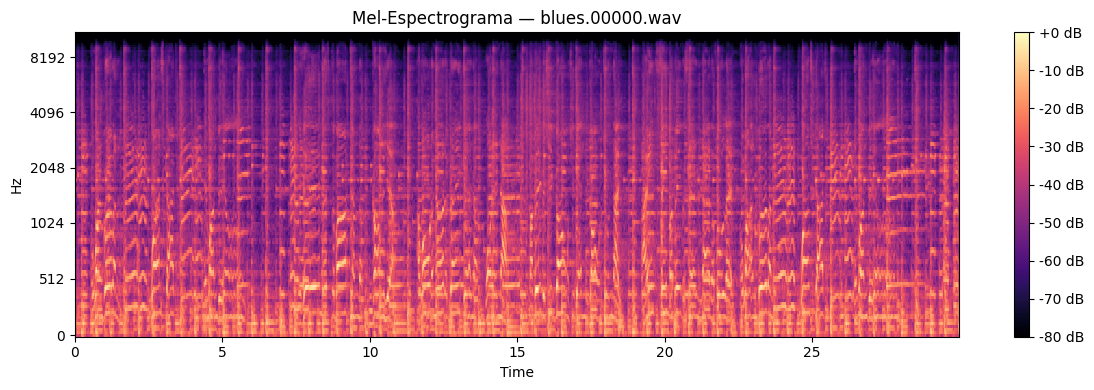

Shape do Mel-Espectrograma: (128, 1292)  (n_mels x frames)


In [29]:
# Parâmetros de áudio e espectrograma
SAMPLE_RATE   = 22050
DURATION      = 30       # segundos por música
N_MELS        = 128      # número de bandas mel
N_FFT         = 2048
HOP_LENGTH    = 512
FIXED_FRAMES  = 1292     # ~30s a 22050Hz com hop=512


def load_melspectrogram(filepath, sr=SAMPLE_RATE, duration=DURATION,
                        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Carrega áudio e extrai Mel-Espectrograma (dB) normalizado."""
    y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
    # Padding se o áudio for menor que o esperado
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


# Exemplo de visualização
if GTZAN_ROOT.exists():
    sample_file = GTZAN_ROOT / 'blues' / 'blues.00000.wav'
    if sample_file.exists():
        mel = load_melspectrogram(sample_file)
        fig, ax = plt.subplots(figsize=(12, 4))
        img = librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                       x_axis='time', y_axis='mel', ax=ax, cmap='magma')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
        ax.set_title('Mel-Espectrograma — blues.00000.wav')
        plt.tight_layout()
        plt.show()
        print(f'Shape do Mel-Espectrograma: {mel.shape}  (n_mels x frames)')
    else:
        print('Arquivo de exemplo não encontrado. Verifique GTZAN_ROOT.')

## 7. Dataset e DataLoader

In [30]:
class GTZANDataset(Dataset):
    """
    Dataset PyTorch para o GTZAN.
    Cada item é um Mel-Espectrograma (1 x N_MELS x FIXED_FRAMES) e um rótulo.
    """

    def __init__(self, entries, gtzan_root, transform=None,
                 fixed_frames=FIXED_FRAMES):
        """
        Args:
            entries: lista de (caminho_relativo, label_str)
            gtzan_root: Path para a raiz do GTZAN (pasta 'genres_original')
            transform: transformações opcionais
            fixed_frames: número de frames a usar (truncar ou paddar)
        """
        self.entries = entries
        self.gtzan_root = Path(gtzan_root)
        self.transform = transform
        self.fixed_frames = fixed_frames

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        rel_path, label_str = self.entries[idx]
        filepath = self.gtzan_root / rel_path

        mel = load_melspectrogram(str(filepath))

        # Ajusta número de frames
        if mel.shape[1] < self.fixed_frames:
            pad_width = self.fixed_frames - mel.shape[1]
            mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant',
                         constant_values=mel.min())
        else:
            mel = mel[:, :self.fixed_frames]

        # Normalização min-max para [0, 1]
        mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)

        # Adiciona dimensão de canal: (1, N_MELS, FIXED_FRAMES)
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)

        if self.transform:
            mel_tensor = self.transform(mel_tensor)

        label = torch.tensor(GENRE2IDX[label_str], dtype=torch.long)
        return mel_tensor, label


def get_dataloaders(fold_data, gtzan_root, batch_size=32):
    """Cria DataLoaders de treino e teste para um fold."""
    train_ds = GTZANDataset(fold_data['train'], gtzan_root)
    test_ds  = GTZANDataset(fold_data['test'],  gtzan_root)

    # num_workers=2 com persistent_workers evita overhead de fork no Colab
    # Se travar, reduza para num_workers=0
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                               shuffle=True,  num_workers=2,
                               pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                               shuffle=False, num_workers=2,
                               pin_memory=True, persistent_workers=True)
    return train_loader, test_loader


print('Classes GTZANDataset e get_dataloaders definidas.')


Classes GTZANDataset e get_dataloaders definidas.


## 8. Arquitetura da CNN

In [31]:
class MusicGenreCNN(nn.Module):
    """
    CNN para classificação de gênero musical a partir de Mel-Espectrogramas.

    Arquitetura:
    - 4 blocos convolucionais (Conv → BN → ReLU → MaxPool → Dropout)
    - 2 camadas fully-connected com Dropout
    - Saída: 10 classes (gêneros GTZAN)
    """

    def __init__(self, n_classes=10, dropout=0.3):
        super(MusicGenreCNN, self).__init__()

        # Bloco 1: 1 -> 32 canais
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),   # reduz: mel/2 x frames/4
            nn.Dropout2d(dropout)
        )

        # Bloco 2: 32 -> 64 canais
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),   # reduz: mel/4 x frames/16
            nn.Dropout2d(dropout)
        )

        # Bloco 3: 64 -> 128 canais
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),   # reduz: mel/8 x frames/64
            nn.Dropout2d(dropout)
        )

        # Bloco 4: 128 -> 256 canais
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),       # saída fixa: 256 x 4 x 4
            nn.Dropout2d(dropout)
        )

        # Classificador
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x


# Visualiza o modelo
model = MusicGenreCNN(n_classes=len(GENRES)).to(DEVICE)
print(model)

# Conta parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParâmetros totais:     {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}')

MusicGenreCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)


## 9. Funções de Treino e Avaliação

In [32]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Treina o modelo por uma época."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in tqdm(loader, desc='Treino', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += inputs.size(0)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    """Avalia o modelo em um conjunto de dados."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Avaliação', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += inputs.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


print('Funções de treino e avaliação definidas.')

Funções de treino e avaliação definidas.


In [33]:
!apt-get install -y ffmpeg -q

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [34]:
def load_melspectrogram(filepath, sr=SAMPLE_RATE, duration=DURATION,
                        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    try:
        y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
    except Exception:
        # Arquivo corrompido — retorna silêncio
        y = np.zeros(sr * duration)

    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

In [35]:
# Passo 1: copiar dataset para disco local (uma vez)
import shutil
LOCAL_DATA = Path('/content/genres_original')
if not LOCAL_DATA.exists():
    print('Copiando...')
    shutil.copytree(GTZAN_ROOT, LOCAL_DATA)
    print('✓ Concluído!')
GTZAN_ROOT = LOCAL_DATA

## 10. Loop de Treinamento com Validação Cruzada 3-Fold

In [36]:
# Hiperparâmetros
EPOCHS      = 10
BATCH_SIZE  = 32
LR          = 1e-3
WEIGHT_DECAY = 1e-4

# Armazena métricas de cada fold
fold_histories = []
fold_results   = []

for fold_data in folds:
    fold_id = fold_data['fold']
    print(f'\n{'='*60}')
    print(f'  FOLD {fold_id}/3')
    print(f'{'='*60}')

    # DataLoaders
    train_loader, test_loader = get_dataloaders(
        fold_data, GTZAN_ROOT, batch_size=BATCH_SIZE
    )

    # Modelo, critério, otimizador e scheduler
    model = MusicGenreCNN(n_classes=len(GENRES)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        test_loss, test_acc, preds, labels_true = eval_epoch(model, test_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_preds = preds
            best_labels = labels_true

        if epoch % 1 == 0:
            print(f'  Época {epoch:3d}/{EPOCHS} | '
                  f'Treino: loss={train_loss:.4f} acc={train_acc:.4f} | '
                  f'Teste: loss={test_loss:.4f} acc={test_acc:.4f}')

    print(f'\n  ✓ Melhor acurácia no fold {fold_id}: {best_acc:.4f}')

    # Salva resultado do fold
    fold_results.append({
        'fold': fold_id,
        'best_acc': best_acc,
        'preds': best_preds,
        'labels': best_labels,
        'f1_macro': f1_score(best_labels, best_preds, average='macro')
    })
    fold_histories.append(history)

print(f'\n{"="*60}')
print('  RESUMO DA VALIDAÇÃO CRUZADA')
print(f'{"="*60}')
accs = [r['best_acc'] for r in fold_results]
f1s  = [r['f1_macro'] for r in fold_results]
for r in fold_results:
    print(f'  Fold {r["fold"]}: Acc={r["best_acc"]:.4f}  F1-macro={r["f1_macro"]:.4f}')
print(f'  Média Acc: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'  Média F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')


  FOLD 1/3


Treino:  20%|██        | 4/20 [00:12<00:41,  2.60s/it]/tmp/ipykernel_8720/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  Época   1/10 | Treino: loss=2.3675 acc=0.1248 | Teste: loss=2.4158 acc=0.0952


Treino:  60%|██████    | 12/20 [00:21<00:11,  1.48s/it]/tmp/ipykernel_8720/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  Época   2/10 | Treino: loss=2.2334 acc=0.1943 | Teste: loss=2.5589 acc=0.0984


...

  Época   8/10 | Treino: loss=1.8548 acc=0.3597 | Teste: loss=1.8311 acc=0.3880


Treino:  20%|██        | 4/20 [00:08<00:27,  1.73s/it]/tmp/ipykernel_8720/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  Época   9/10 | Treino: loss=1.8678 acc=0.3708 | Teste: loss=1.8426 acc=0.3659


Treino:  20%|██        | 4/20 [00:09<00:31,  1.98s/it]/tmp/ipykernel_8720/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
                                                          

  Época  10/10 | Treino: loss=1.8396 acc=0.3946 | Teste: loss=1.8514 acc=0.3596

  ✓ Melhor acurácia no fold 3: 0.3975

  RESUMO DA VALIDAÇÃO CRUZADA
  Fold 1: Acc=0.4063  F1-macro=0.3361
  Fold 2: Acc=0.3513  F1-macro=0.2821
  Fold 3: Acc=0.3975  F1-macro=0.3653
  Média Acc: 0.3850 ± 0.0241
  Média F1:  0.3278 ± 0.0344


## 11. Visualização: Curvas de Treino

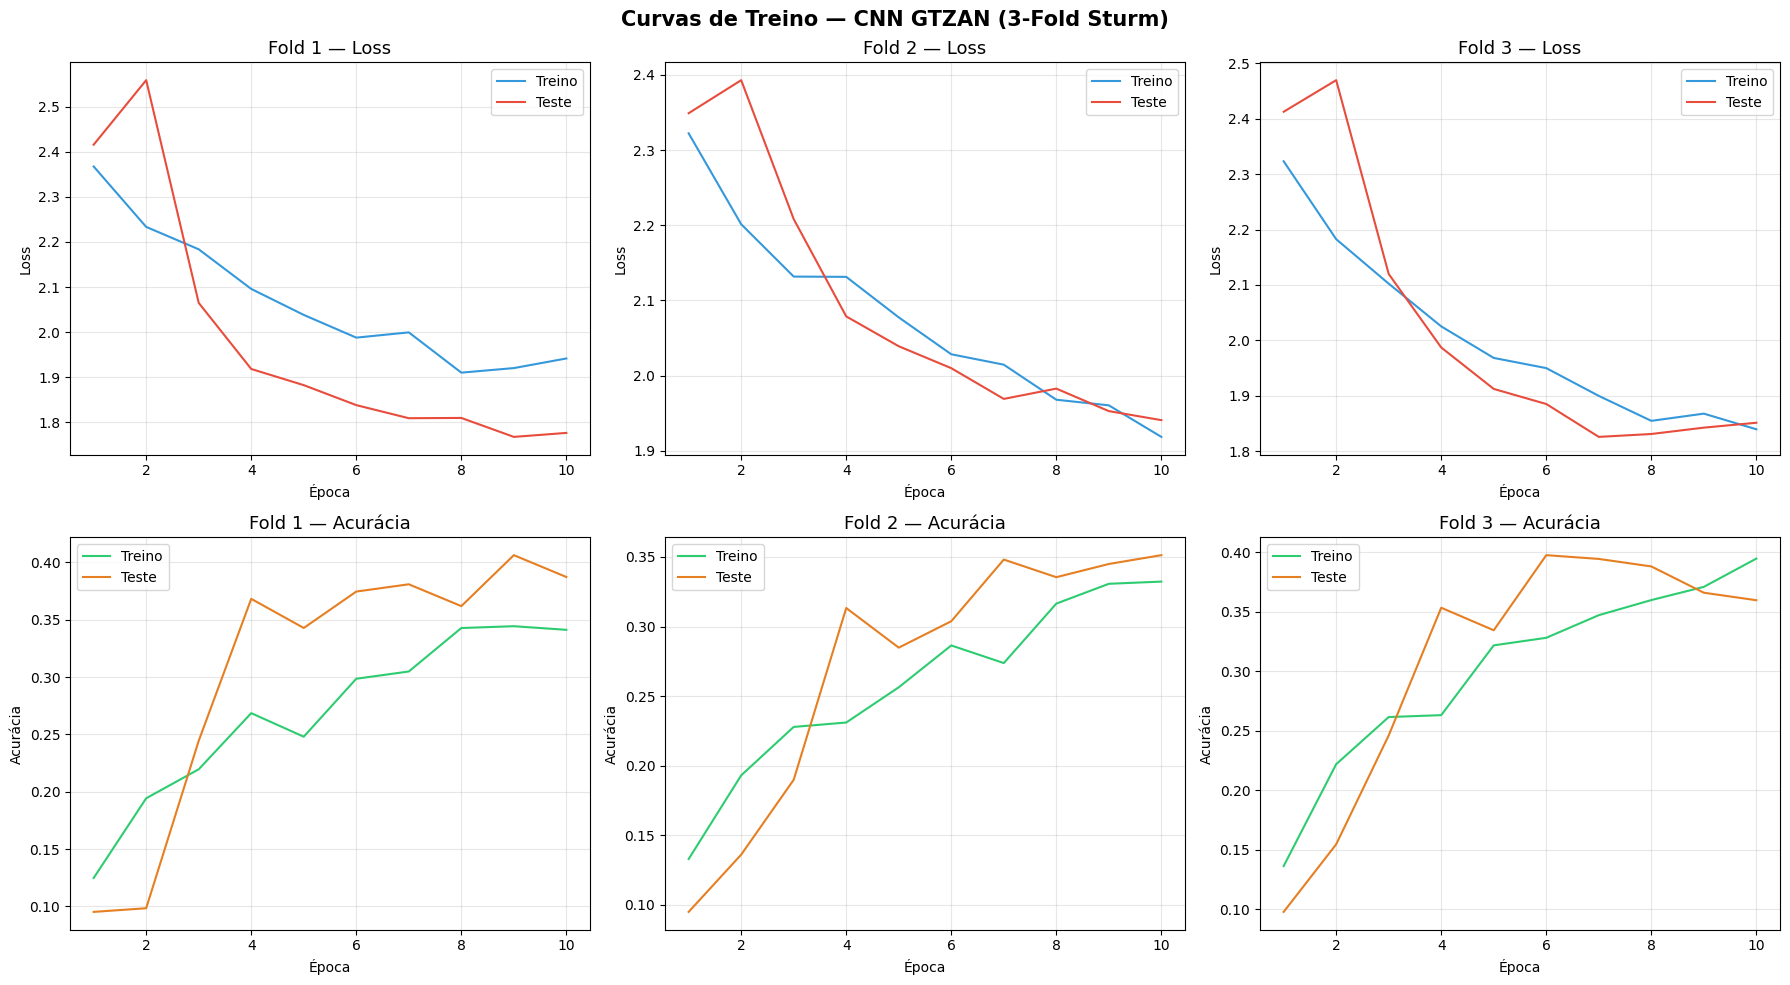

✓ Salvo em: /content/drive/MyDrive/gtzan_outputs/training_curves.png


In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (history, ax_loss, ax_acc) in enumerate(
    zip(fold_histories, axes[0], axes[1])
):
    fold_id = i + 1
    epochs = range(1, len(history['train_loss']) + 1)

    ax_loss.plot(epochs, history['train_loss'], label='Treino', color='#3498db')
    ax_loss.plot(epochs, history['test_loss'],  label='Teste',  color='#e74c3c')
    ax_loss.set_title(f'Fold {fold_id} — Loss', fontsize=13)
    ax_loss.set_xlabel('Época')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs, history['train_acc'], label='Treino', color='#2ecc71')
    ax_acc.plot(epochs, history['test_acc'],  label='Teste',  color='#e67e22')
    ax_acc.set_title(f'Fold {fold_id} — Acurácia', fontsize=13)
    ax_acc.set_xlabel('Época')
    ax_acc.set_ylabel('Acurácia')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

plt.suptitle('Curvas de Treino — CNN GTZAN (3-Fold Sturm)', fontsize=15, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'training_curves.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Salvo em: {out_path}')


## 12. Visualização: Matriz de Confusão (Melhor Fold)

Visualizando o fold 1 (melhor acurácia: 0.4063)


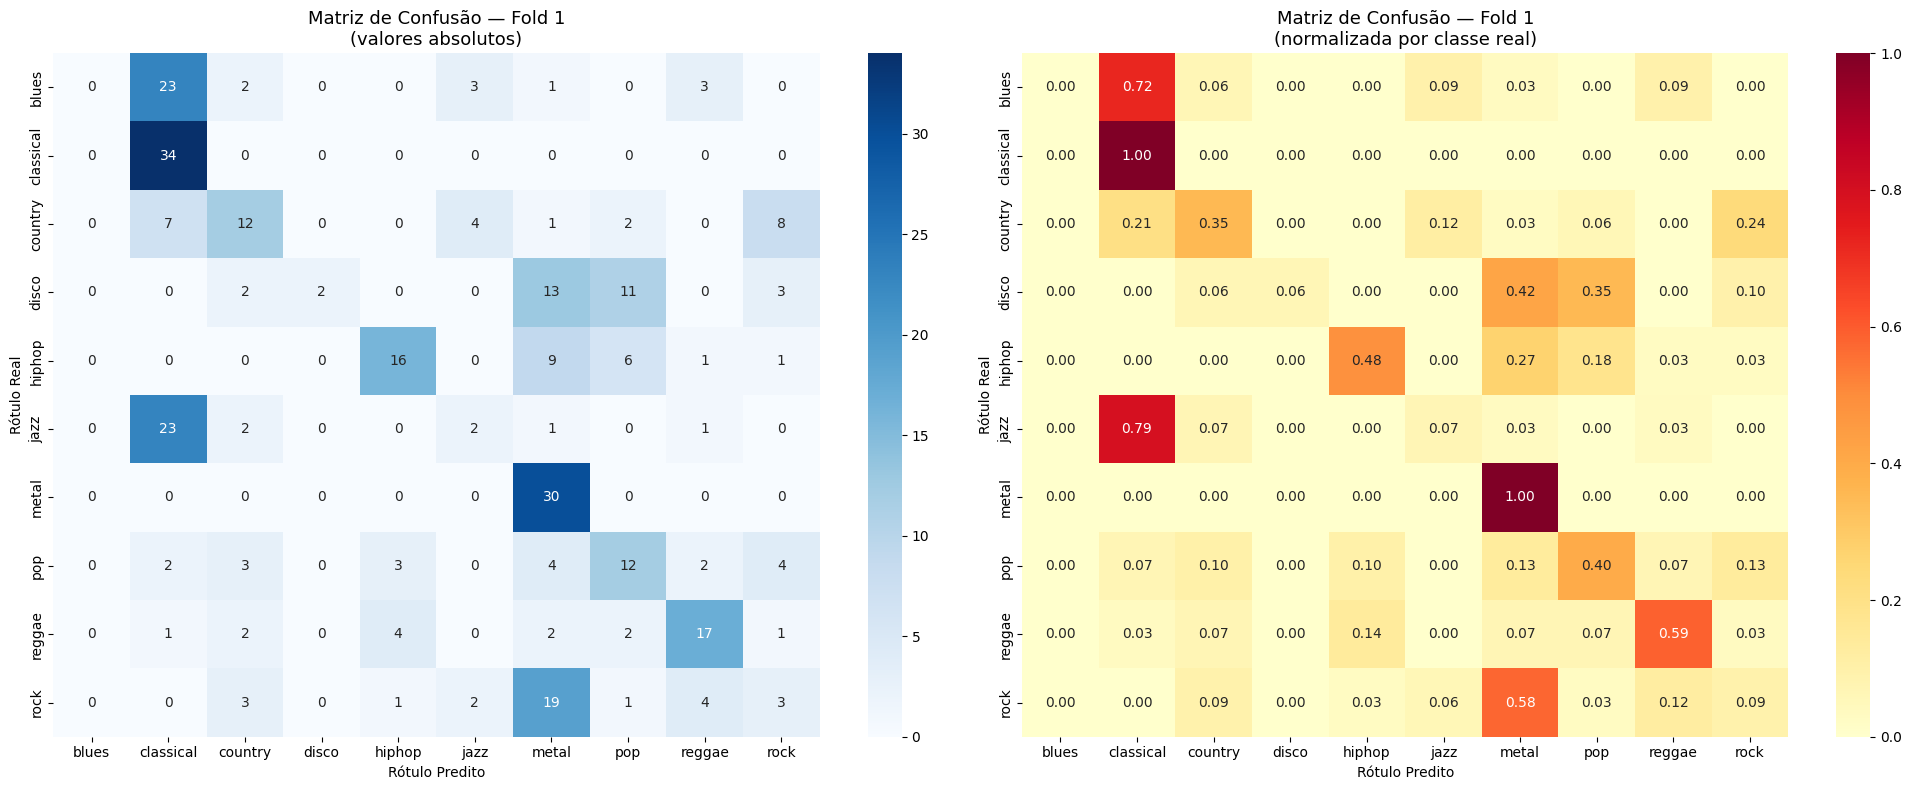

✓ Salvo em: /content/drive/MyDrive/gtzan_outputs/confusion_matrix.png


In [38]:
# Escolhe o fold com maior acurácia
best_fold = max(fold_results, key=lambda x: x['best_acc'])
print(f"Visualizando o fold {best_fold['fold']} (melhor acurácia: {best_fold['best_acc']:.4f})")

cm = confusion_matrix(best_fold['labels'], best_fold['preds'])
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=axes[0])
axes[0].set_title(f'Matriz de Confusão — Fold {best_fold["fold"]}\n(valores absolutos)',
                  fontsize=13)
axes[0].set_ylabel('Rótulo Real')
axes[0].set_xlabel('Rótulo Predito')

# Matriz normalizada
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=GENRES, yticklabels=GENRES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title(f'Matriz de Confusão — Fold {best_fold["fold"]}\n(normalizada por classe real)',
                  fontsize=13)
axes[1].set_ylabel('Rótulo Real')
axes[1].set_xlabel('Rótulo Predito')

plt.tight_layout()
out_path = OUTPUT_DIR / 'confusion_matrix.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Salvo em: {out_path}')


## 13. Relatório de Classificação

In [39]:
print(f"{'='*60}")
print(f"  RELATÓRIO DE CLASSIFICAÇÃO — Fold {best_fold['fold']}")
print(f"{'='*60}")
print(classification_report(
    best_fold['labels'], best_fold['preds'],
    target_names=GENRES, digits=4
))

# Tabela resumo de todos os folds
print('\nResumo por fold:')
df_results = pd.DataFrame([{
    'Fold': r['fold'],
    'Acurácia': f"{r['best_acc']:.4f}",
    'F1-Macro': f"{r['f1_macro']:.4f}"
} for r in fold_results])
df_results.loc[len(df_results)] = [
    'Média ± DP',
    f"{np.mean(accs):.4f} ± {np.std(accs):.4f}",
    f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}"
]
print(df_results.to_string(index=False))

  RELATÓRIO DE CLASSIFICAÇÃO — Fold 1
              precision    recall  f1-score   support

       blues     0.0000    0.0000    0.0000        32
   classical     0.3778    1.0000    0.5484        34
     country     0.4615    0.3529    0.4000        34
       disco     1.0000    0.0645    0.1212        31
      hiphop     0.6667    0.4848    0.5614        33
        jazz     0.1818    0.0690    0.1000        29
       metal     0.3750    1.0000    0.5455        30
         pop     0.3529    0.4000    0.3750        30
      reggae     0.6071    0.5862    0.5965        29
        rock     0.1500    0.0909    0.1132        33

    accuracy                         0.4063       315
   macro avg     0.4173    0.4048    0.3361       315
weighted avg     0.4165    0.4063    0.3368       315


Resumo por fold:
      Fold        Acurácia        F1-Macro
         1          0.4063          0.3361
         2          0.3513          0.2821
         3          0.3975          0.3653
Média ± DP 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 14. Salvando o Modelo do Melhor Fold

In [40]:
# Retreina o melhor fold para salvar o modelo final
best_fold_id = best_fold['fold'] - 1
best_fold_data = folds[best_fold_id]

train_loader, _ = get_dataloaders(best_fold_data, GTZAN_ROOT, batch_size=BATCH_SIZE)

final_model = MusicGenreCNN(n_classes=len(GENRES)).to(DEVICE)
final_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
final_optimizer = optim.AdamW(final_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
final_scheduler = optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=EPOCHS)

print(f'Treinando modelo final (Fold {best_fold["fold"]})...')
for epoch in range(1, EPOCHS + 1):
    loss, acc = train_epoch(final_model, train_loader, final_criterion, final_optimizer, DEVICE)
    final_scheduler.step()
    if epoch % 10 == 0:
        print(f'  Época {epoch}/{EPOCHS} — Loss: {loss:.4f}  Acc: {acc:.4f}')

# Salva no Google Drive
checkpoint = {
    'model_state': final_model.state_dict(),
    'genres': GENRES,
    'genre2idx': GENRE2IDX,
    'best_fold': best_fold['fold'],
    'best_acc': best_fold['best_acc'],
    'hyperparams': {
        'n_mels': N_MELS, 'n_fft': N_FFT, 'hop_length': HOP_LENGTH,
        'sample_rate': SAMPLE_RATE, 'duration': DURATION,
        'fixed_frames': FIXED_FRAMES
    }
}
model_path = OUTPUT_DIR / 'gtzan_cnn_best.pth'
torch.save(checkpoint, model_path)
print(f'\n✓ Modelo salvo em: {model_path}')


Treinando modelo final (Fold 1)...


Treino:  60%|██████    | 12/20 [00:25<00:15,  1.93s/it]/tmp/ipykernel_8720/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Treino:  40%|████      | 8/20 [00:18<00:20,  1.74s/it]/tmp/ipykernel_8720/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Treino:  60%|██████    

  Época 10/10 — Loss: 1.9198  Acc: 0.3254

✓ Modelo salvo em: /content/drive/MyDrive/gtzan_outputs/gtzan_cnn_best.pth


## 15. Inferência: Classificando uma Nova Música

In [41]:
def predict_genre(audio_path, model, device=DEVICE):
    """
    Prediz o gênero musical de um arquivo de áudio.
    Retorna: (gênero predito, dicionário de probabilidades)
    """
    mel = load_melspectrogram(audio_path)

    # Ajusta frames
    if mel.shape[1] < FIXED_FRAMES:
        mel = np.pad(mel, ((0, 0), (0, FIXED_FRAMES - mel.shape[1])),
                     mode='constant', constant_values=mel.min())
    else:
        mel = mel[:, :FIXED_FRAMES]

    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    x = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()

    predicted_genre = GENRES[np.argmax(probs)]
    prob_dict = {genre: float(probs[i]) for i, genre in enumerate(GENRES)}

    return predicted_genre, prob_dict


# Exemplo de uso
# predicted, probs = predict_genre('caminho/para/musica.wav', final_model)
# print(f'Gênero predito: {predicted}')
# print('Probabilidades:')
# for genre, prob in sorted(probs.items(), key=lambda x: -x[1]):
#     bar = '█' * int(prob * 30)
#     print(f'  {genre:12s} {bar} {prob:.3f}')

print('Função predict_genre() definida e pronta para uso.')
print("Descomente as linhas acima e forneça um caminho de áudio para testar.")

Função predict_genre() definida e pronta para uso.
Descomente as linhas acima e forneça um caminho de áudio para testar.


---
## Referências

- **Dataset GTZAN:** Tzanetakis, G., & Cook, P. (2002). Musical genre classification of audio signals. *IEEE Transactions on Speech and Audio Processing*, 10(5), 293–302.

- **Filtro Sturm:** Sturm, B. L. (2013). The GTZAN dataset: Its contents, its faults, their effects on evaluation, and its future use. *arXiv preprint arXiv:1306.1461*.

- **Folds utilizados:** Foleis, J. H., & Tavares, T. F. (2020). Texture selection for automatic music genre classification. *Applied Soft Computing*, 89, 106127. https://doi.org/10.1016/j.asoc.2020.106127